# Contextual Scouting — UEFA Euro 2024
## Hypothesis 2 — `xEPV` & Decision Quality

This notebook builds the **xEPV** layer on top of the calibrated xPass model
(`H2-Contextual_Decision_Making.ipynb`). For every event we already have a
long-form table of **candidate teammates** (the alternative set) with the
probability that the pass completes; here we attach the *expected value* of
each such pass via the EPV grid from H1.

Scope of this notebook (§0-3):
1. Setup and load the alternatives table + EPV grid.
2. Evaluate EPV at every candidate target — and at its *mirrored* location.
3. Combine into **xEPV** via a symmetric reward/penalty:

$$\text{xEPV} \;=\; \text{xPass}\,\cdot\,\text{EPV}(x,y)\;-\;(1-\text{xPass})\,\cdot\,s\,\cdot\,\text{EPV}(105-x,\,y)$$

The Decision Quality index (regret / rank / aggregation by player) will be
built in a follow-up notebook once the xEPV distribution is validated here.


## Section 0 — Setup


In [1]:
import sys
from pathlib import Path

# Auto-reload edited src/ modules so a stale kernel copy never shadows
# the file on disk (this is what caused the plot_dq_scatter min_n TypeError)
%load_ext autoreload
%autoreload 2

# Locate the project root (the parent containing both H1 and H2)
NB_DIR = Path.cwd().resolve()
ROOT = NB_DIR
while ROOT.parent != ROOT and not (ROOT / 'Decision_Quality').is_dir():
    ROOT = ROOT.parent
if not (ROOT / 'Decision_Quality').is_dir():
    raise RuntimeError(f'project root not found above {NB_DIR}')

# Put H2 on the path so `import src` resolves to H2's package
H2_DIR = ROOT / 'Decision_Quality'
if str(H2_DIR) not in sys.path:
    sys.path.insert(0, str(H2_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as cfg
from src import xepv

print(f'project root        : {ROOT}')
print(f'H2 package          : {H2_DIR / "src"}')
print(f'pitch dimensions    : {cfg.PITCH_LENGTH_M} x {cfg.PITCH_WIDTH_M} m')
print(f'xEPV failure scale  : {cfg.XEPV_FAILURE_SCALE}')

project root        : /Users/matteovezzoli/Desktop/Contextual-Football-Scouting
H2 package          : /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/Decision_Quality/src
pitch dimensions    : 105.0 x 68.0 m
xEPV failure scale  : 1.0


## Section 1 — Load the alternatives table

`alternatives.parquet` is the long-form table built in the xPass notebook:
one row per **(event, candidate teammate)** with the 13 features and the
**calibrated xPass** already attached. We keep the rich representation here
because the xEPV / Decision Quality layer needs to score *all* candidates,
not just the chosen one.


In [2]:
alt = pd.read_parquet(cfg.ALTERNATIVES_PATH)

n_events = alt['event_id'].nunique()
n_cands_per_event = alt.groupby('event_id').size()

print(f'alternatives rows   : {len(alt):,}')
print(f'events              : {n_events:,}')
print(f'candidates / event  : mean = {n_cands_per_event.mean():.2f}, '
      f'median = {int(n_cands_per_event.median())}, '
      f'range = [{n_cands_per_event.min()}, {n_cands_per_event.max()}]')
print(f'chosen rows         : {int(alt["is_chosen"].sum()):,}  '
      f'(should equal events: {n_events:,})')
print(f'xPass range         : [{alt["xpass"].min():.3f}, '
      f'{alt["xpass"].max():.3f}]')

assert int(alt['is_chosen'].sum()) == n_events, 'one chosen row per event expected'

alt.head(3)


alternatives rows   : 222,274
events              : 30,913
candidates / event  : mean = 7.19, median = 7, range = [1, 10]
chosen rows         : 30,913  (should equal events: 30,913)
xPass range         : [0.076, 0.990]


,event_id,match_id,pass_complete,candidate_idx,is_chosen,target_x_m,target_y_m,pass_distance,pass_angle_forward,start_x,...,min_dist_def_to_receiver,min_perp_dist_to_line,pass_lane_density_score,sender_pressure_count_25,min_dist_def_to_sender,defender_density_3m_receiver,teammate_density_5m_receiver,pass_height_low,pass_height_high,xpass
0,401caf44-957b-4c6c-925c-85978734732b,3942819,1,0,False,29.215247,48.521220,17.552923,94.606638,30.625,...,13.536801,7.659045,0.309827,0,8.228132,0,0,0,0,0.990000
1,401caf44-957b-4c6c-925c-85978734732b,3942819,1,1,True,35.284900,20.688756,11.338104,65.732670,30.625,...,10.345862,9.851342,0.179257,0,8.228132,0,0,0,0,0.990000
2,401caf44-957b-4c6c-925c-85978734732b,3942819,1,2,False,35.951000,63.643106,33.050070,80.726381,30.625,...,17.765576,6.714069,0.454381,0,8.228132,0,0,0,1,0.978993


## Section 2 — EPV at candidate locations

The EPV grid lives in H1 (`Space_Control_and_Value/data/EPV_grid.csv`).
It is a 32 × 50 lookup of pitch positions (rows = Y / width, cols = X /
length), with attacking direction = increasing X. Values range from
~0.004 (own goal area) to ~0.57 (opponent goal area).

`xepv.epv_at` is a **vectorised bilinear interpolation** equivalent to
H1's `epv_pipeline._epv_at`. We use it to look up EPV at *every* candidate
target position — and, separately, at the **mirror position** `(105 - x, y)`,
which represents the opponent's value at the same world point from their
attacking direction. The mirror term is what we will use to penalise
turnovers in §3.


In [3]:
epv_grid = xepv.load_epv_grid()
print(f'EPV grid shape      : {epv_grid.shape}  (rows=Y/width, cols=X/length)')
print(f'EPV value range     : [{epv_grid.min():.4f}, {epv_grid.max():.4f}]')

# Sanity spot-checks at canonical locations
print()
print('EPV at canonical pitch locations:')
for (x, y, name) in [(0, 34, 'own goal mouth'),
                     (17.5, 34, 'own box, center'),
                     (52.5, 34, 'midfield, center'),
                     (87.5, 34, 'opp box, center'),
                     (105, 34, 'opp goal mouth'),
                     (90, 10, 'opp half, wide')]:
    v = float(xepv.epv_at(epv_grid, x, y))
    print(f'  ({x:5.1f}, {y:5.1f}) [{name:18s}]  EPV = {v:.4f}')


EPV grid shape      : (32, 50)  (rows=Y/width, cols=X/length)
EPV value range     : [0.0041, 0.5714]

EPV at canonical pitch locations:
  (  0.0,  34.0) [own goal mouth    ]  EPV = 0.0085
  ( 17.5,  34.0) [own box, center   ]  EPV = 0.0083
  ( 52.5,  34.0) [midfield, center  ]  EPV = 0.0139
  ( 87.5,  34.0) [opp box, center   ]  EPV = 0.0976
  (105.0,  34.0) [opp goal mouth    ]  EPV = 0.5714
  ( 90.0,  10.0) [opp half, wide    ]  EPV = 0.0372


In [4]:
# Attach epv_target + epv_mirror to the alternatives table (no xepv yet)
alt = alt.copy()
alt['epv_target'] = xepv.epv_at(epv_grid, alt['target_x_m'].values,
                                          alt['target_y_m'].values)
alt['epv_mirror'] = xepv.epv_at(epv_grid,
                                cfg.PITCH_LENGTH_M - alt['target_x_m'].values,
                                alt['target_y_m'].values)

# Sanity: distributions
summary = alt[['epv_target', 'epv_mirror']].describe(
    percentiles=[.05, .25, .5, .75, .95]).round(4)
print('EPV at candidate targets and their mirrors:')
print(summary)

# How does EPV behave along the pitch length?
print()
print('Mean EPV by target_x band (10 m wide):')
bins = np.arange(0, 106, 10)
tmp = alt.assign(x_band=pd.cut(alt['target_x_m'], bins=bins, include_lowest=True))
print(tmp.groupby('x_band', observed=True)['epv_target'].agg(['mean', 'count']).round(4))


EPV at candidate targets and their mirrors:
        epv_target   epv_mirror
count  222274.0000  222274.0000
mean        0.0257       0.0192
std         0.0301       0.0377
min         0.0042       0.0041
5%          0.0082       0.0073
25%         0.0124       0.0092
50%         0.0169       0.0121
75%         0.0261       0.0165
95%         0.0806       0.0423
max         0.5714       0.5714

Mean EPV by target_x band (10 m wide):
                  mean  count
x_band                       
(-0.001, 10.0]  0.0073   3169
(10.0, 20.0]    0.0077   7509
(20.0, 30.0]    0.0087  12561
(30.0, 40.0]    0.0103  18936
(40.0, 50.0]    0.0125  27296
(50.0, 60.0]    0.0149  37648
(60.0, 70.0]    0.0186  38430
(70.0, 80.0]    0.0268  36906
(80.0, 90.0]    0.0500  29339
(90.0, 100.0]   0.1174  10186


## Section 3 — xEPV: expected value of a candidate pass

**Formula.** For each candidate pass with completion probability $p$ and
target $(x, y)$:

$$
\text{xEPV} \;=\; p \cdot \text{EPV}(x, y)
              \;-\; (1 - p) \cdot s \cdot \text{EPV}(105 - x,\, y)
$$

where $s = $ `cfg.XEPV_FAILURE_SCALE` (default $1.0$).

**Why the mirror term.** Treating EPV symmetrically means a turnover gives
the opponent a position whose value equals our EPV at the *flipped* world
point. The pitch is geometrically symmetric, so the mirrored EPV cell is a
defensible proxy for "what is the opponent worth if they recover here?".
Choosing $s = 1$ is the strongest, most pessimistic assumption (opponent
gets clean possession instantly). Lowering $s$ (e.g. 0.5) softens the
penalty if it turns out to discourage ambitious passes too much — we will
look at this in the distributions below.

**Interpretation.**
- $\text{xEPV} > 0$ — net positive expected value (reward outweighs
  expected turnover cost).
- $\text{xEPV} < 0$ — pass is expected to lose us EPV on average
  (typically: low $p$ in own half, where the mirror is very valuable).
- $\text{xEPV} \approx p \cdot \text{EPV}(x, y)$ when the mirror is
  small (i.e. the target is itself far from our own goal, so a turnover
  doesn't hand the opponent a dangerous position).


In [5]:
# Compute xEPV using the helper (so the formula lives in one place)
alt = xepv.compute_xepv(alt, epv_grid)

stats = alt[['xpass', 'epv_target', 'epv_mirror', 'xepv']].describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(4)
print('Distribution of xPass, EPV terms, and xEPV across all candidates:')
print(stats)

print()
print(f'Share with xEPV < 0  : {(alt["xepv"] < 0).mean():.2%}')
print(f'Share with xEPV >= 0 : {(alt["xepv"] >= 0).mean():.2%}')


Distribution of xPass, EPV terms, and xEPV across all candidates:
             xpass   epv_target   epv_mirror         xepv
count  222274.0000  222274.0000  222274.0000  222274.0000
mean        0.8245       0.0257       0.0192       0.0158
std         0.1899       0.0301       0.0377       0.0156
min         0.0764       0.0042       0.0041      -0.3337
1%          0.2666       0.0069       0.0063      -0.0150
5%          0.4174       0.0082       0.0073      -0.0006
25%         0.7281       0.0124       0.0092       0.0085
50%         0.8970       0.0169       0.0121       0.0132
75%         0.9814       0.0261       0.0165       0.0199
95%         0.9900       0.0806       0.0423       0.0421
99%         0.9900       0.1560       0.1608       0.0731
max         0.9900       0.5714       0.5714       0.3895

Share with xEPV < 0  : 5.47%
Share with xEPV >= 0 : 94.53%


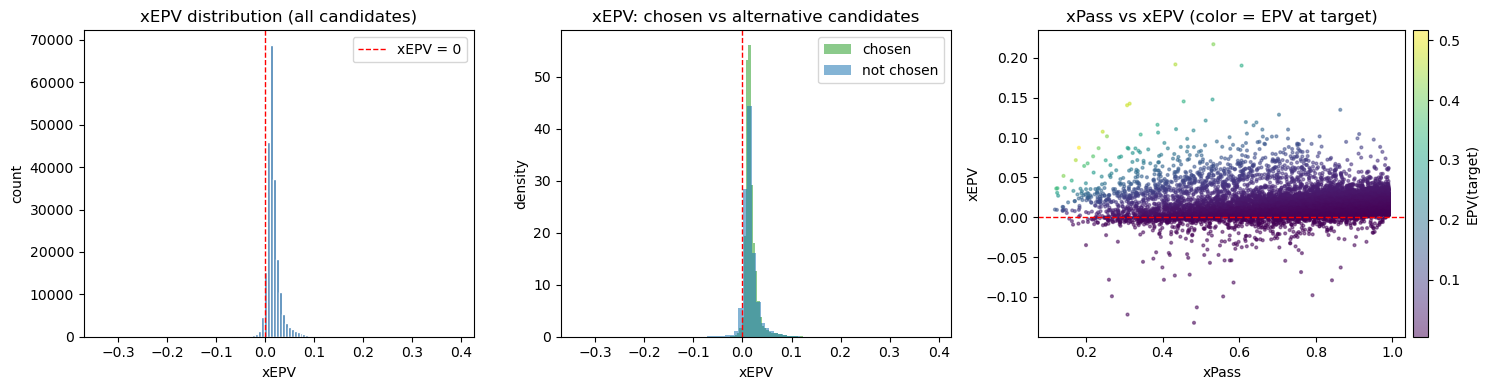

In [6]:
# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(alt['xepv'], bins=120, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', lw=1, ls='--', label='xEPV = 0')
axes[0].set_title('xEPV distribution (all candidates)')
axes[0].set_xlabel('xEPV')
axes[0].set_ylabel('count')
axes[0].legend(loc='upper right')

# Chosen vs non-chosen
for is_chosen, label, color in [(True, 'chosen', 'C2'),
                                (False, 'not chosen', 'C0')]:
    sub = alt.loc[alt['is_chosen'] == is_chosen, 'xepv']
    axes[1].hist(sub, bins=80, alpha=0.55, density=True, label=label, color=color)
axes[1].axvline(0, color='red', lw=1, ls='--')
axes[1].set_title('xEPV: chosen vs alternative candidates')
axes[1].set_xlabel('xEPV')
axes[1].set_ylabel('density')
axes[1].legend()

# Scatter: xpass vs xepv, coloured by EPV at target
samp = alt.sample(n=min(15000, len(alt)), random_state=0)
sc = axes[2].scatter(samp['xpass'], samp['xepv'],
                     c=samp['epv_target'], cmap='viridis',
                     s=4, alpha=0.5)
axes[2].axhline(0, color='red', lw=1, ls='--')
axes[2].set_title('xPass vs xEPV (color = EPV at target)')
axes[2].set_xlabel('xPass')
axes[2].set_ylabel('xEPV')
fig.colorbar(sc, ax=axes[2], fraction=0.04, pad=0.02, label='EPV(target)')

plt.tight_layout()
plt.show()


In [7]:
# How does the chosen candidate rank by xEPV inside its event?
# Quick preview — the formal Decision Quality index comes in a follow-up notebook.
rank_within_event = (
    alt.groupby('event_id')['xepv']
       .rank(method='min', ascending=False)
       .astype(int)
)
alt['xepv_rank'] = rank_within_event

rank_chosen = alt.loc[alt['is_chosen'], 'xepv_rank']
n_cands = alt.groupby('event_id').size()

print('Rank of the CHOSEN candidate by xEPV (1 = highest xEPV in the event):')
print(rank_chosen.value_counts().sort_index().head(10).to_string())
print()
print(f'Share where chosen == rank 1 (xEPV-optimal) : '
      f'{(rank_chosen == 1).mean():.2%}')
print(f'Share where chosen is in top 3              : '
      f'{(rank_chosen <= 3).mean():.2%}')
print(f'Mean rank (out of mean {n_cands.mean():.1f} candidates) : '
      f'{rank_chosen.mean():.2f}')


Rank of the CHOSEN candidate by xEPV (1 = highest xEPV in the event):
xepv_rank
1     4690
2     5332
3     5657
4     5092
5     4156
6     2990
7     1863
8      879
9      247
10       7

Share where chosen == rank 1 (xEPV-optimal) : 15.17%
Share where chosen is in top 3              : 50.72%
Mean rank (out of mean 7.2 candidates) : 3.68


## Section 4 — Visual sanity check: does the xEPV formula identify sensible passes?

Numbers in §3 say the formula behaves: bounded, ~5% of candidates with
xEPV < 0, chosen rank distribution informative-but-not-trivial. But the
interesting question is **qualitative**: when xEPV says "this is great" or
"this is bad", does the pass look that way on the pitch?

This section pulls three sets of representative events and plots them
with all the candidate teammates colored by xEPV. The candidate label
is `xPass | xEPV·100`.

> **Scale convention — important.** Every panel in this section displays
> xEPV **multiplied by 100** for readability. It is **not** a percentage.
> xEPV is in the same units as EPV (probability of scoring in the
> current possession), with a typical range of `[-0.30, +0.45]`. So a
> panel label of `+44.8` means xEPV = `0.448`, and `+2.4` means
> xEPV = `0.024`. The same rescaling is used in §4.4 (axes labelled
> "× 100") and in the player-level metric in §5.

We load the corpus once to enrich `alternatives.parquet` with sender
position, opponents, and player/team for the titles.


In [8]:
from src import corpus
import matplotlib.patches as patches
import matplotlib.cm as cm
from matplotlib.colors import TwoSlopeNorm

# Load corpus (cached) — needed for sender position, opponents, titles
dq_corpus = corpus.build_corpus()

# Attach context columns to alt for convenience (one row per event for ctx)
ctx_cols = ['event_id', 'player', 'team', 'minute', 'start_x_m', 'start_y_m',
            'opponents', 'teammates', 'pass_complete']
ctx = dq_corpus[ctx_cols].drop_duplicates(subset='event_id').set_index('event_id')

# alt already has xepv + xepv_rank from §3; keep it as the main table.
print(f'corpus events       : {len(dq_corpus):,}')
print(f'alt events covered  : {alt["event_id"].isin(ctx.index).sum() // alt.groupby("event_id").size().mean():.0f}')
print(f'alt rows            : {len(alt):,}')


Loading H1 corpus
  rows                  : 38,166
Pass metadata
360 frames (teammates + opponents)
Filtering exclusions
  headers removed       : 432
  GK senders removed    : 1,786
  pass-into-space (>12m): 5,034
  no-frame removed      : 1
  retained              : 30,913 / 38,166 (81.0%)
Saved corpus            : /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/Decision_Quality/data/dq_corpus.csv  (30,913 rows)
corpus events       : 30,913
alt events covered  : 30913
alt rows            : 222,274


In [9]:
# Inline xEPV pitch helpers (kept here for now; will promote to viz.py
# if we end up reusing them)

def _draw_pitch_compact(ax):
    L, W = cfg.PITCH_LENGTH_M, cfg.PITCH_WIDTH_M
    ax.set_facecolor('#f5f5f5')
    ax.add_patch(patches.Rectangle((0, 0), L, W, color='white', zorder=0))
    ax.plot([0, L, L, 0, 0], [0, 0, W, W, 0], color='black', lw=1.0)
    ax.plot([L/2, L/2], [0, W], color='black', lw=1.0)
    ax.add_patch(patches.Circle((L/2, W/2), 9.15, fill=False, edgecolor='black', lw=1.0))
    ax.add_patch(patches.Rectangle((0, (W-40.32)/2), 16.5, 40.32,
                                    fill=False, edgecolor='black', lw=1.0))
    ax.add_patch(patches.Rectangle((L-16.5, (W-40.32)/2), 16.5, 40.32,
                                    fill=False, edgecolor='black', lw=1.0))
    ax.set_xlim(-2, L+2); ax.set_ylim(-2, W+2)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])


def _xepv_cmap_norm(values):
    """TwoSlopeNorm centered at 0 → red(neg) / white(0) / green(pos)."""
    vmin = min(float(np.min(values)), -1e-6)
    vmax = max(float(np.max(values)),  1e-6)
    return TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)


def _opp_xy(opp_field):
    if opp_field is None: return np.empty((0, 2))
    if isinstance(opp_field, float) and np.isnan(opp_field): return np.empty((0, 2))
    if hasattr(opp_field, '__len__') and len(opp_field) == 0: return np.empty((0, 2))
    return np.asarray([[float(p[0]), float(p[1])] for p in opp_field], dtype=float).reshape(-1, 2)


def plot_xepv_alternatives_ax(ax, event_id, alt_df, ctx_df):
    ev_alt = alt_df.loc[alt_df['event_id'] == event_id].sort_values('candidate_idx')
    if event_id not in ctx_df.index or ev_alt.empty:
        ax.set_title(f'event not found: {event_id[:8]}…', color='red')
        return
    r = ctx_df.loc[event_id]
    sx, sy = float(r['start_x_m']), float(r['start_y_m'])

    _draw_pitch_compact(ax)

    # Opponents
    opp = _opp_xy(r.get('opponents'))
    if opp.shape[0]:
        ax.scatter(opp[:, 0], opp[:, 1], color='black', s=45, zorder=3,
                   edgecolors='white', linewidths=0.5)

    # Sender
    ax.scatter([sx], [sy], marker='D', s=140, color='#00BFFF',
               edgecolors='black', linewidths=1.2, zorder=8)

    # Candidates, colored by xEPV
    norm = _xepv_cmap_norm(ev_alt['xepv'].values)
    cmap = cm.RdYlGn
    chosen_row = None
    for _, row in ev_alt.iterrows():
        x, y = float(row['target_x_m']), float(row['target_y_m'])
        v, p = float(row['xepv']), float(row['xpass'])
        color = cmap(norm(v))
        is_chosen = bool(row['is_chosen'])
        ax.scatter([x], [y], s=210, color=color,
                   edgecolors='black', linewidths=3.2 if is_chosen else 0.8,
                   zorder=6)
        ax.annotate(f'{p:.2f}\n{v*100:+.1f}', xy=(x, y), xytext=(x+1.2, y+1.2),
                    fontsize=7.5, zorder=7)
        if is_chosen: chosen_row = row

    # Arrow sender → chosen
    if chosen_row is not None:
        cx, cy = float(chosen_row['target_x_m']), float(chosen_row['target_y_m'])
        ax.annotate('', xy=(cx, cy), xytext=(sx, sy),
                    arrowprops=dict(arrowstyle='->', color='#222', lw=2.0, alpha=0.7),
                    zorder=4)

    # Title with chosen xEPV, rank, regret
    chosen_xepv = float(chosen_row['xepv']) if chosen_row is not None else float('nan')
    chosen_rank = int(chosen_row['xepv_rank']) if chosen_row is not None else 0
    best_xepv = float(ev_alt['xepv'].max())
    n_cand = len(ev_alt)
    outcome = 'OK' if int(r.get('pass_complete', 0)) == 1 else 'X'
    ax.set_title(
        f"{r.get('player', '?')} ({r.get('team', '?')}) min {int(r.get('minute', 0))}'  [{outcome}]\n"
        f"chosen xEPV={chosen_xepv*100:+.2f}  rank {chosen_rank}/{n_cand}  "
        f"best={best_xepv*100:+.2f}  regret={(best_xepv-chosen_xepv)*100:.2f}",
        fontsize=9, loc='left')


def plot_xepv_grid(event_ids, alt_df, ctx_df, ncols=2):
    n = len(event_ids)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(8.0 * ncols, 5.6 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, eid in zip(axes, event_ids):
        plot_xepv_alternatives_ax(ax, eid, alt_df, ctx_df)
    for ax in axes[n:]: ax.axis('off')
    plt.tight_layout()
    return fig

print('helpers ready')


helpers ready


### §4.1 — Top xEPV (chosen): are they obviously valuable?

The 3 *chosen* passes with the highest xEPV. These should look like
clean attacking actions in the final third — high xPass and high
EPV(target). If we see weird stuff here (e.g. low-quality backward
passes), something is off.


Top 3 chosen passes by xEPV:
                            event_id  xpass  epv_target  epv_mirror   xepv  target_x_m  target_y_m
bb6285f8-5995-4891-86e9-118f216c195b 0.5837      0.4603      0.0077 0.2655    100.4485     34.1254
0e60b6e9-385d-4424-965b-bfaadc169919 0.6070      0.3451      0.0076 0.2065     99.1825     34.9331
1853be28-281a-4aef-b940-0eb159b385f5 0.5702      0.3399      0.0076 0.1906     99.1653     30.7818


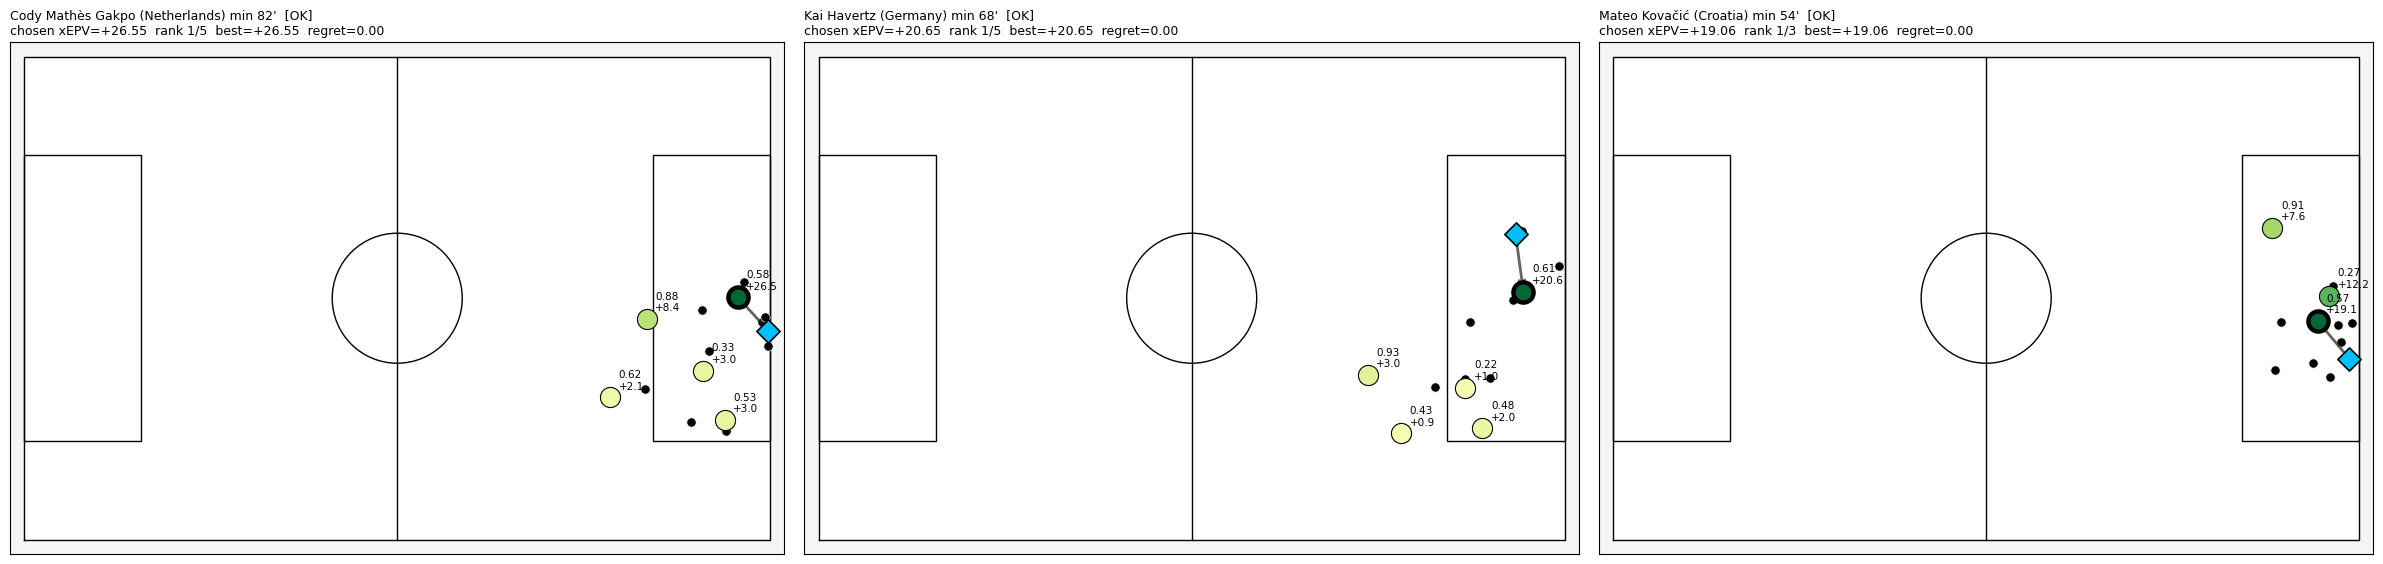

In [10]:
chosen = alt[alt['is_chosen']].copy()

top_xepv = chosen.nlargest(3, 'xepv')
print('Top 3 chosen passes by xEPV:')
print(top_xepv[['event_id', 'xpass', 'epv_target', 'epv_mirror',
                'xepv', 'target_x_m', 'target_y_m']].round(4).to_string(index=False))

plot_xepv_grid(top_xepv['event_id'].tolist(), alt, ctx, ncols=3)
plt.show()


### §4.2 — Worst xEPV (chosen): are they obviously risky?

The 3 *chosen* passes with the lowest (most negative) xEPV. These
should look like risky distributions in the defensive third — low xPass
with the mirror penalty close to opponent's attacking goal. If the
worst panels show innocuous-looking passes, the mirror term is being
too harsh.


Worst 3 chosen passes by xEPV:
                            event_id  xpass  epv_target  epv_mirror    xepv  target_x_m  target_y_m  pass_complete
6421bbc0-70d2-4a88-a620-0fa1357a018e 0.5230      0.0072      0.2242 -0.1032      4.7963     27.4924              0
cf1a5fa3-541e-4680-8199-8e69c1bac20b 0.3795      0.0081      0.1465 -0.0878     10.9618     36.7914              0
ea411e9c-db96-4037-a796-d1bc5a252cb0 0.7600      0.0076      0.3852 -0.0867      5.4698     31.5273              0


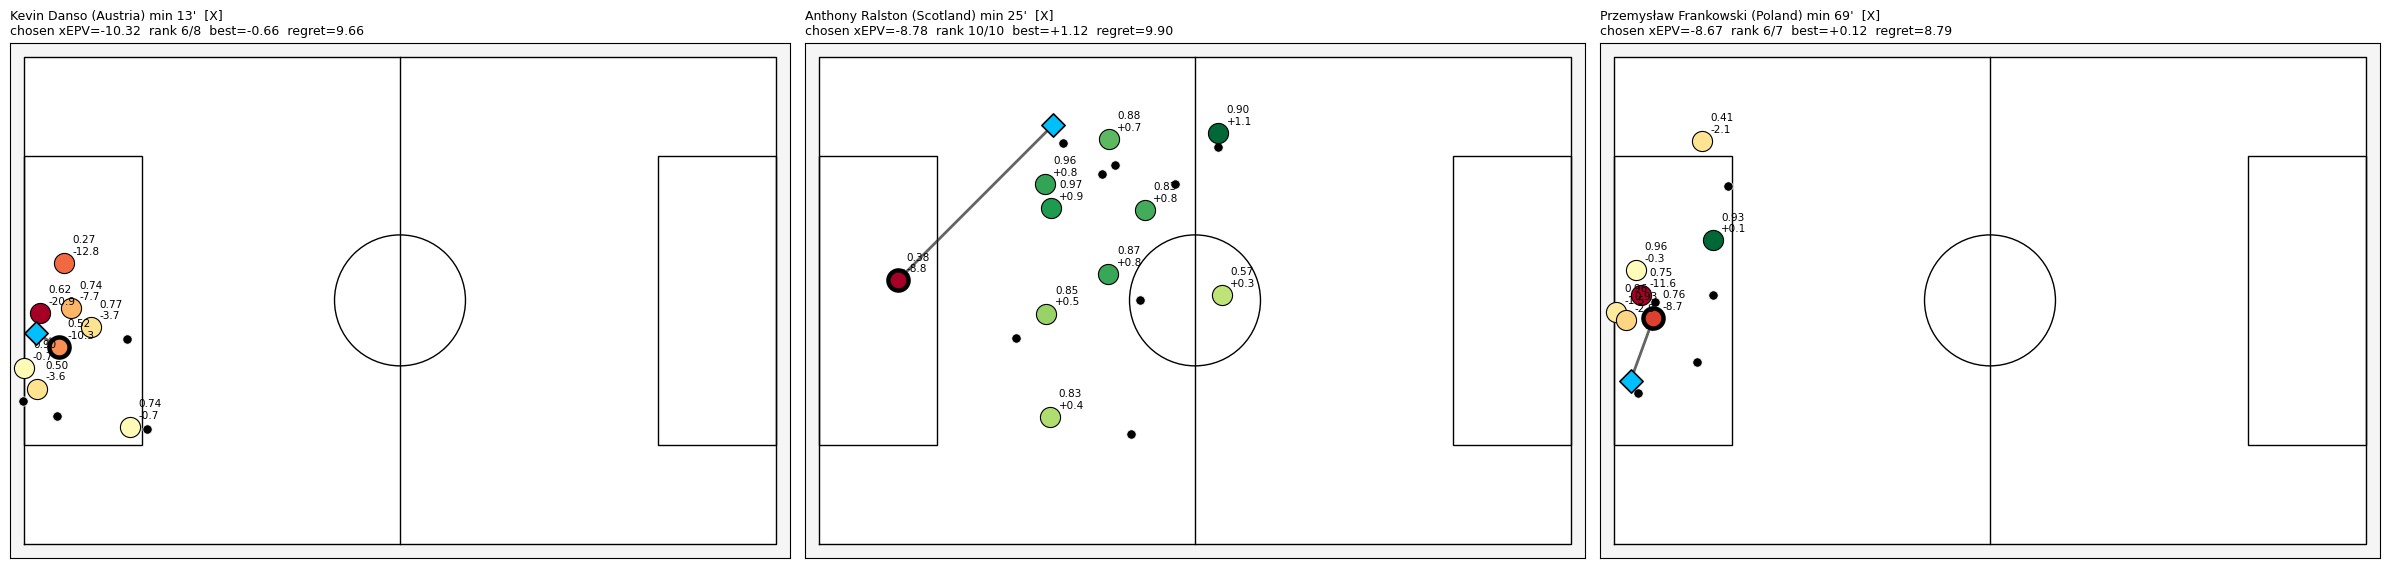

In [11]:
worst_xepv = chosen.nsmallest(3, 'xepv')
print('Worst 3 chosen passes by xEPV:')
print(worst_xepv[['event_id', 'xpass', 'epv_target', 'epv_mirror',
                  'xepv', 'target_x_m', 'target_y_m', 'pass_complete']].round(4).to_string(index=False))

plot_xepv_grid(worst_xepv['event_id'].tolist(), alt, ctx, ncols=3)
plt.show()


### §4.3 — High regret: chosen rank low, much better option visible

Events where the chosen pass ranks **bad** in xEPV (rank >= 5) and the
gap between best xEPV and chosen xEPV is large. These are the cases
the Decision Quality index in the next notebook will surface. Read
them as: the green dot is the option xEPV says the player should have
picked; the chosen (thick black border) is somewhere else.


High-regret chosen passes (rank >= 5, top by regret):
                            event_id  xpass   xepv  best_xepv  regret  xepv_rank  n_cand  pass_complete
85b3ef66-4627-4540-81b1-8d7231cd63e0 0.9900 0.0431     0.3895  0.3464          5       6              1
6f0b0de7-1a04-4279-bf71-1538d7f33573 0.9899 0.0242     0.3669  0.3427          5       9              1
2ecc9cc5-ea56-4121-8543-61cfec511f8b 0.9431 0.0173     0.2695  0.2522          5       9              1


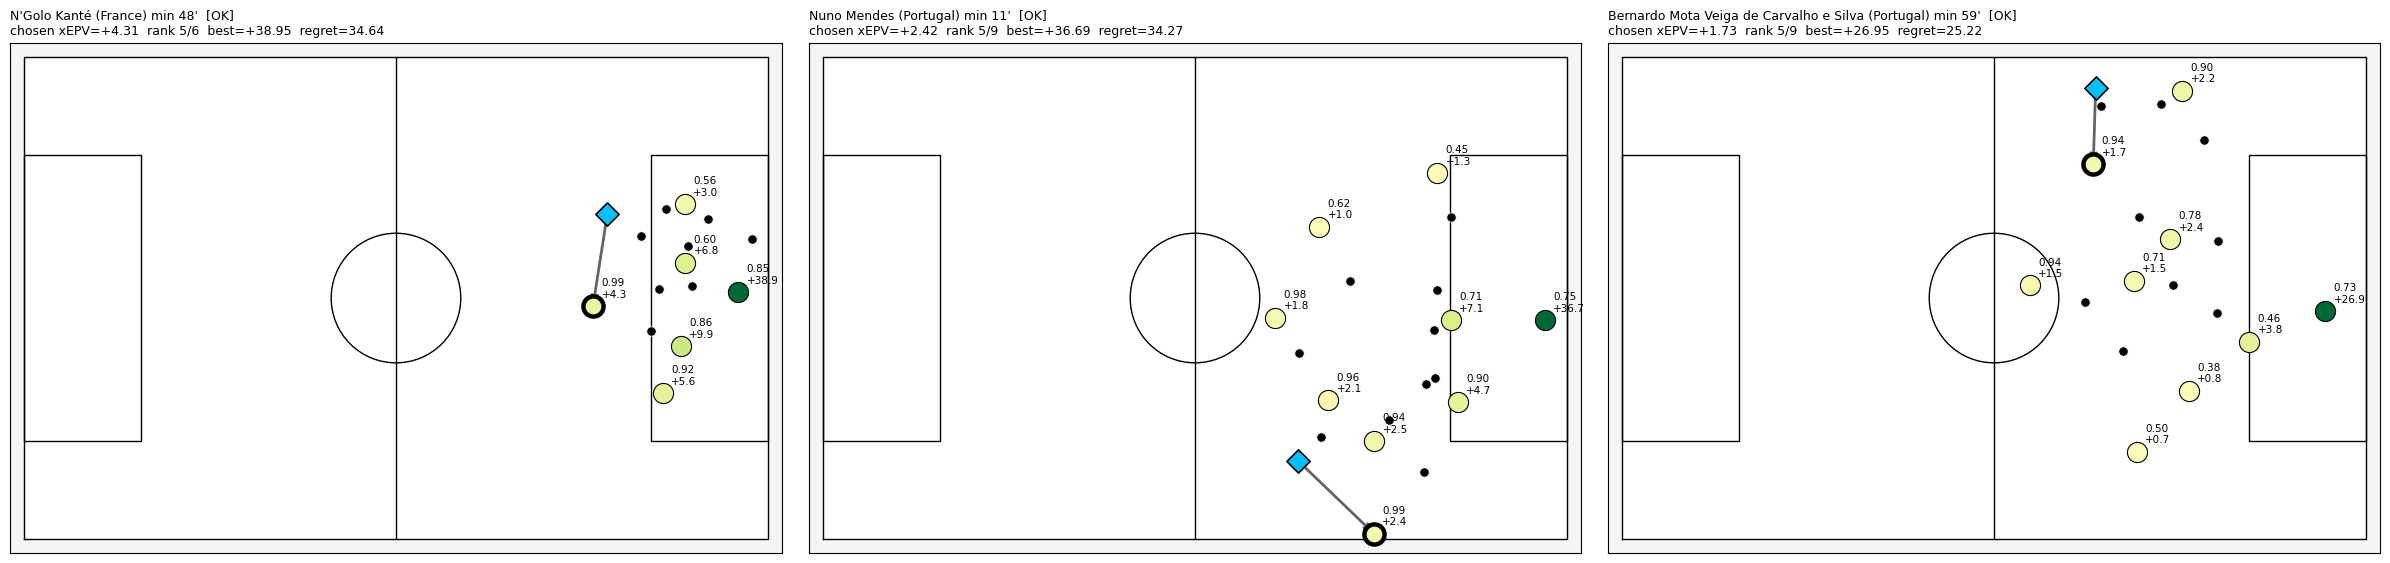

In [12]:
chosen_regret = chosen.copy()
chosen_regret['best_xepv'] = chosen_regret['event_id'].map(
    alt.groupby('event_id')['xepv'].max())
chosen_regret['regret'] = chosen_regret['best_xepv'] - chosen_regret['xepv']
chosen_regret['n_cand']  = chosen_regret['event_id'].map(
    alt.groupby('event_id').size())

# Filter to events with enough alternatives + rank >= 5
high_regret = (chosen_regret
               .query('xepv_rank >= 5 and n_cand >= 6')
               .nlargest(3, 'regret'))

print('High-regret chosen passes (rank >= 5, top by regret):')
print(high_regret[['event_id', 'xpass', 'xepv', 'best_xepv', 'regret',
                   'xepv_rank', 'n_cand', 'pass_complete']].round(4).to_string(index=False))

plot_xepv_grid(high_regret['event_id'].tolist(), alt, ctx, ncols=3)
plt.show()


### §4.4 — Aggregate cross-checks

Two summary plots:

(a) **Mean chosen xEPV by sender pitch zone.** Should be monotone:
passes from advanced positions yield more value on average.

(b) **Reward vs penalty decomposition by xPass decile.** A naive
"mean xEPV by xPass" plot can look counter-intuitive because of
**selection bias**: players choose hard (low-xPass) passes precisely
when the reward is large enough to make the risk worth it. We
decompose the formula into its two terms so the dynamic is visible:

- `reward  = xPass · EPV(target)` — green bar
- `penalty = (1 - xPass) · EPV(mirror)` — red bar
- `net xEPV = reward - penalty` — blue bar

Expected pattern: in the low-xPass decile, both reward AND penalty
are large (players go for valuable targets and risk a costly turnover);
in the high-xPass deciles, penalty collapses to ~0 (safe passes) and
the reward is what's left.


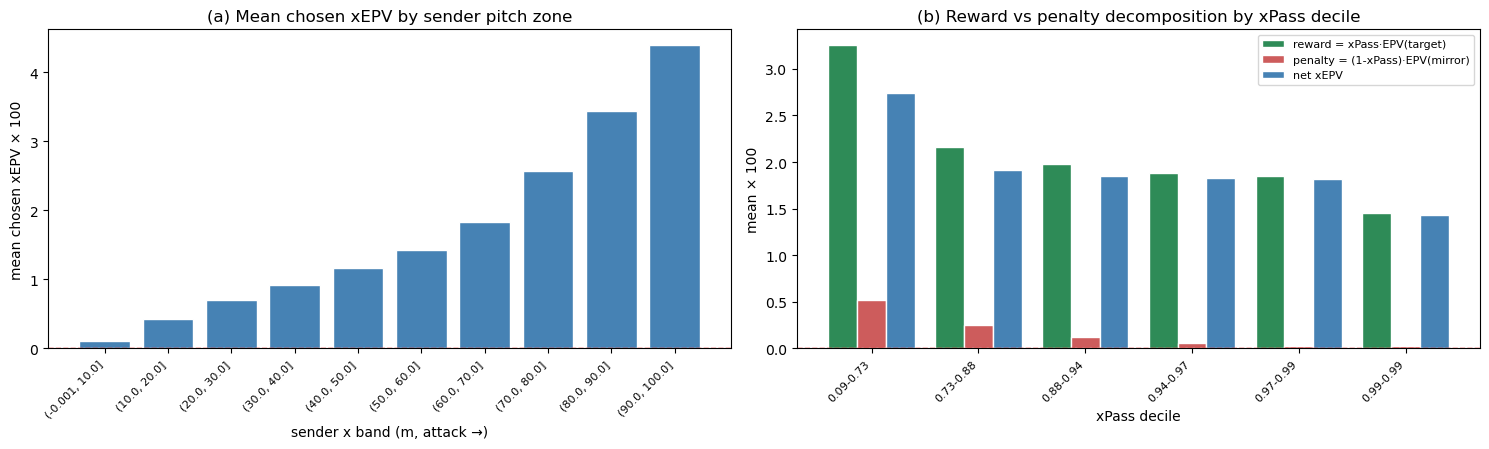


Decomposition by xPass decile:
   xpass_decile  reward  penalty  xepv
(0.0904, 0.729]    3.26     0.52  2.74
 (0.729, 0.876]    2.16     0.25  1.91
 (0.876, 0.944]    1.98     0.12  1.85
 (0.944, 0.973]    1.89     0.06  1.83
 (0.973, 0.986]    1.85     0.03  1.82
  (0.986, 0.99]    1.46     0.02  1.43


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))

chosen_ctx = chosen.merge(ctx[['start_x_m']], left_on='event_id', right_index=True)

# (a) Mean chosen xEPV by sender x-band
bins = np.arange(0, 106, 10)
chosen_ctx['sender_x_band'] = pd.cut(chosen_ctx['start_x_m'], bins=bins, include_lowest=True)
agg_zone = (chosen_ctx.groupby('sender_x_band', observed=True)['xepv']
                      .agg(['mean', 'count']).reset_index())
axes[0].bar(range(len(agg_zone)), agg_zone['mean'].values * 100,
            color='steelblue', edgecolor='white')
axes[0].set_xticks(range(len(agg_zone)))
axes[0].set_xticklabels([str(b) for b in agg_zone['sender_x_band']],
                        rotation=45, ha='right', fontsize=8)
axes[0].axhline(0, color='red', lw=1, ls='--')
axes[0].set_xlabel('sender x band (m, attack →)')
axes[0].set_ylabel('mean chosen xEPV × 100')
axes[0].set_title('(a) Mean chosen xEPV by sender pitch zone')

# (b) Reward / penalty / net decomposition by xpass decile
chosen_ctx['reward']  = chosen_ctx['xpass']      * chosen_ctx['epv_target']
chosen_ctx['penalty'] = (1 - chosen_ctx['xpass']) * cfg.XEPV_FAILURE_SCALE * chosen_ctx['epv_mirror']
chosen_ctx['xpass_decile'] = pd.qcut(chosen_ctx['xpass'], q=10, duplicates='drop')

agg_d = (chosen_ctx.groupby('xpass_decile', observed=True)
                   [['reward', 'penalty', 'xepv']]
                   .mean().reset_index())

x = np.arange(len(agg_d))
w = 0.27
axes[1].bar(x - w, agg_d['reward'].values  * 100, width=w,
            color='seagreen',  edgecolor='white', label='reward = xPass·EPV(target)')
axes[1].bar(x,     agg_d['penalty'].values * 100, width=w,
            color='indianred', edgecolor='white', label='penalty = (1-xPass)·EPV(mirror)')
axes[1].bar(x + w, agg_d['xepv'].values    * 100, width=w,
            color='steelblue', edgecolor='white', label='net xEPV')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'{iv.left:.2f}-{iv.right:.2f}' for iv in agg_d['xpass_decile']],
                        rotation=45, ha='right', fontsize=8)
axes[1].axhline(0, color='red', lw=1, ls='--')
axes[1].set_xlabel('xPass decile')
axes[1].set_ylabel('mean × 100')
axes[1].set_title('(b) Reward vs penalty decomposition by xPass decile')
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

# Print the table too for inspection
print('\nDecomposition by xPass decile:')
print(agg_d.assign(
    reward=lambda d: (d['reward']  * 100).round(2),
    penalty=lambda d: (d['penalty'] * 100).round(2),
    xepv=lambda d: (d['xepv']    * 100).round(2),
).to_string(index=False))


## Section 5 — Decision Quality: the final design

§4 used `regret = best_xepv − chosen_xepv` to *pick events to plot*, and
that stays the right tool for case audit. For the **per-player index** we
tested several aggregations and most failed in instructive ways. This is
the design we keep.

**Index — Score.** Per event, `Score` is the share of in-frame
alternatives whose xEPV is at or below the xEPV of the pass the player
actually chose (events with at least 2 alternatives). The player Score is
the mean over their events. The headline is the **within macro-role
percentile** of that player Score.

Why Score and not regret or absolute xEPV:

- It is normalised **inside each event**, so the absolute value level of
  the pitch zone cancels. Role means come out flat, the positional bias
  is gone by construction.
- It is a **rank**, so it does not punish players who generate many good
  options (regret did: Modrić, Alexander-Arnold sank on penetrations).
- Recognised decision makers land where football expects once aggregation
  is per player (Kroos, De Bruyne near the top of their roles).

**Honest label.** It measures the rate of *per-pass value-optimal
selection*. It does not credit deliberate tempo control, because xEPV is a
per-pass quantity with no game state. Tempo controllers (Barella, Kimmich,
Xhaka) read mid by selection style, not by error. Declared scope limit, in
the same spirit as gravity being flagged experimental in H1.

**Value Impact (companion).** `mean(chosen_xepv − mean(alternatives))`.
Shown next to the index. Correlated with it (Spearman ρ ≈ 0.76 within role), so it is
not an independent axis, it is the value-weighted view of the same signal
(the role `epv_added` plays next to the percentile in H1).

**Pool.** 135 minutes only, the same cutoff as H1, one authoritative role
per player from `player_space_control_aggregated.csv`. No minimum pass
count: the H2 pool is identical to H1 (272 players, same pool for both
hypotheses); `n` is exposed so low-sample players are visible.

**Graph.** A quality vs value scatter (Score percentile on X, Value Impact
on Y), the player highlighted among their role peers. **No radar**: the
geom_type decomposition inverts structurally on penetration and is not
publishable.


In [14]:
# §5.1 — Build the Decision Quality table (logic lives in src/decision_quality.py)
#
# The notebook is only the orchestrator. `build` reuses the alt table that
# already has xEPV (§3) and the corpus context (§4), aggregates per player on
# H1's 135-min / one-role pool, computes the single DQ_index percentile, and
# writes the website CSV.

from src import decision_quality as dqm
from src import viz

dq = dqm.build(alt=alt, corpus_df=dq_corpus, epv_grid=epv_grid, write=True)

print(f'players written : {len(dq)}  ->  {cfg.PLAYER_DQ_PATH.name}')
print(f'per role        : {dq["macro_role"].value_counts().to_dict()}')
print()
print('columns:', list(dq.columns))
dq.head()


players written : 272  ->  player_decision_quality.csv
per role        : {'MID': 65, 'CB': 61, 'FB': 57, 'WIDE': 37, 'FW': 32, 'CAM': 20}

columns: ['player', 'team', 'primary_role', 'macro_role', 'minutes_played', 'n_decisions', 'DQ_index', 'score', 'score_sd', 'value_impact', 'value_impact_centered', 'delta_xepv_median', 'avg_miss_cost', 'elite_per90', 'poor_per90', 'accuracy_pct', 'worst_choice_pct']


,player,team,primary_role,macro_role,minutes_played,n_decisions,DQ_index,score,score_sd,value_impact,value_impact_centered,delta_xepv_median,avg_miss_cost,elite_per90,poor_per90,accuracy_pct,worst_choice_pct
0,Roland Sallai,Hungary,Left Attacking Midfield,CAM,283,50,100.0,0.627619,0.269370,0.002614,0.000737,0.002759,0.011001,2.226148,0.954064,14.000000,2.000000
1,Qazim Laçi,Albania,Center Attacking Midfield,MID,164,31,100.0,0.681682,0.297316,0.006741,0.006369,0.005316,0.013580,5.487805,1.097561,32.258065,3.225806
2,Wout Weghorst,Netherlands,Center Forward,FW,158,21,100.0,0.830102,0.256174,0.009610,0.005614,0.005725,0.012649,5.696203,0.569620,47.619048,4.761905
3,Patrick Wimmer,Austria,Right Wing,WIDE,149,27,100.0,0.774030,0.253931,0.007859,0.005260,0.003901,0.006971,6.644295,0.604027,40.740741,0.000000
4,Anthony Ralston,Scotland,Right Wing Back,FB,262,44,100.0,0.734407,0.269540,0.004954,0.002706,0.005080,0.010555,4.122137,1.030534,27.272727,2.272727


In [15]:
# §5.2 — Sanity check
#
# Recognised decision makers should sit where football expects, and the
# role means of Score should be roughly flat (zone bias gone). The
# storytelling companions (elite/poor per 90) should track DQ_index
# within a role: high index => more elite reads, fewer poor choices.

WATCH = ['Toni Kroos', 'Luka Modrić', 'Kevin De Bruyne',
         'Rodrigo Hernández Cascante', 'Nicolò Barella', 'İlkay Gündoğan',
         'Joshua Kimmich', 'Granit Xhaka', 'Declan Rice', 'Jude Bellingham']
w = dq[dq['player'].isin(WATCH)].copy()
w['name'] = w['player'].str.split().str[-1]
print('Watchlist (DQ_index = Score percentile within role):')
print(w[['name', 'macro_role', 'n_decisions', 'score', 'score_sd',
         'value_impact', 'elite_per90', 'poor_per90', 'DQ_index']]
        .round(4).sort_values('DQ_index', ascending=False).to_string(index=False))
print()
print('Role means of Score (flat => zone bias gone):')
print(dq.groupby('macro_role')['score'].mean().round(3).to_string())
print()
# elite/poor per 90 are per-MINUTE rates, so they legitimately carry
# involvement volume, not only selectivity. Compare only WITHIN a role.
print('Role means — elite_per90 / poor_per90 (compare within role only):')
print(dq.groupby('macro_role')[['elite_per90', 'poor_per90']].mean().round(2).to_string())

Watchlist (DQ_index = Score percentile within role):
      name macro_role  n_decisions  score  score_sd  value_impact  elite_per90  poor_per90  DQ_index
     Kroos        MID          379 0.6138    0.2709        0.0016      10.5773      4.0825      87.7
    Bruyne        CAM          136 0.6112    0.3001        0.0015       5.7600      3.6000      85.0
  Gündoğan        CAM          134 0.5963    0.2774        0.0014       4.9476      2.5916      70.0
  Cascante        MID          315 0.5687    0.2933        0.0000       6.7669      5.7519      64.6
      Rice        MID          390 0.5543    0.2642       -0.0001       4.6889      4.1679      55.4
Bellingham        CAM          283 0.5814    0.2842        0.0011       5.2545      4.0419      50.0
    Modrić        MID          169 0.5449    0.3066       -0.0003      10.1250      8.6250      44.6
     Xhaka        MID          296 0.5405    0.2941       -0.0006       5.3374      6.9939      40.0
   Barella        MID          193 0.4

In [16]:
# §5.3 — Leaderboards: who decides best and worst
#
# DQ_index is the within-role percentile, so reading it across roles is
# fair. value_impact is in xEPV units (×100 to read).

cols = ['player', 'team', 'macro_role', 'n_decisions', 'DQ_index',
        'score', 'value_impact', 'accuracy_pct']

print('TOP 15 decision makers (DQ_index = Score percentile within role):')
print(dq.nlargest(15, 'DQ_index')[cols].round(4).to_string(index=False))
print()
print('BOTTOM 15:')
print(dq.nsmallest(15, 'DQ_index')[cols].round(4).to_string(index=False))
print()
print('Top 3 per macro role:')
best = (dq.sort_values('DQ_index', ascending=False)
          .groupby('macro_role').head(3)
          .sort_values(['macro_role', 'DQ_index'], ascending=[True, False]))
print(best[cols].round(3).to_string(index=False))

TOP 15 decision makers (DQ_index = Score percentile within role):
                         player        team macro_role  n_decisions  DQ_index  score  value_impact  accuracy_pct
                  Roland Sallai     Hungary        CAM           50     100.0 0.6276        0.0026       14.0000
                     Qazim Laçi     Albania        MID           31     100.0 0.6817        0.0067       32.2581
                  Wout Weghorst Netherlands         FW           21     100.0 0.8301        0.0096       47.6190
                 Patrick Wimmer     Austria       WIDE           27     100.0 0.7740        0.0079       40.7407
                Anthony Ralston    Scotland         FB           44     100.0 0.7344        0.0050       27.2727
                Marin Pongracic     Croatia         CB           73     100.0 0.6708        0.0025       16.4384
           Răzvan Gabriel Marin     Romania        MID           68      98.5 0.6476        0.0015       27.9412
José Ignacio Fernández Iglesia

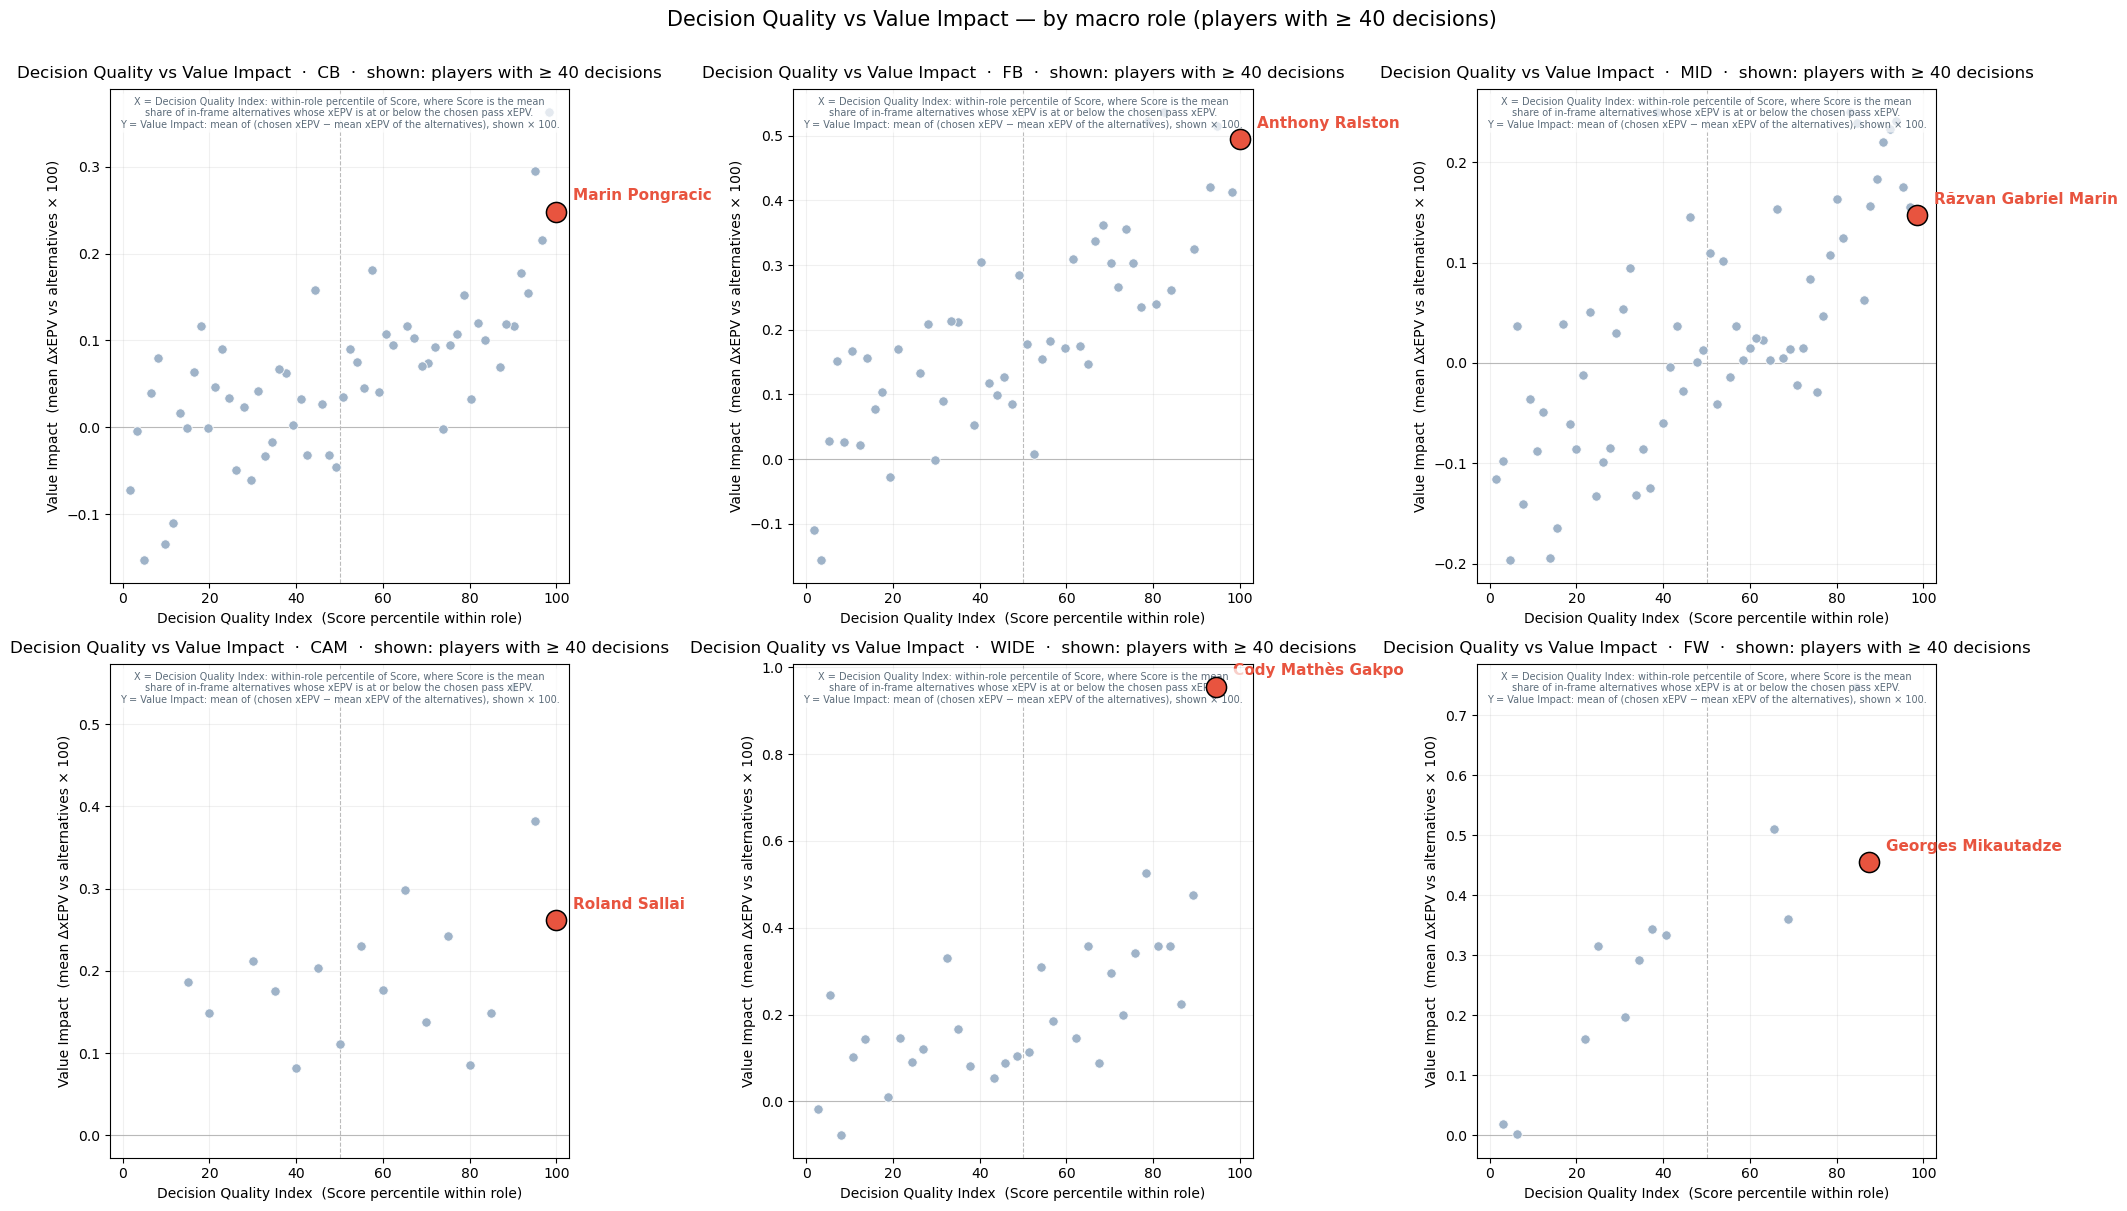

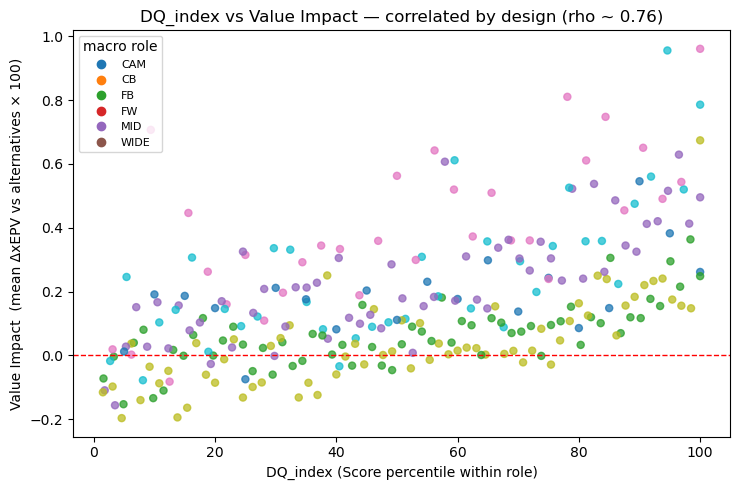

In [17]:
# §5.4 — The player-page graph for every macro role
#
# One scatter per role, the top decision maker of the role highlighted.
# MIN_N is a DISPLAY-ONLY threshold: a few players with very few decisions
# (e.g. one or two matches) produce extreme points that distort the
# picture. It filters the graph only. The index and the CSV stay the full
# 272, no floor, by design — n_decisions is in the table so
# low-sample players remain visible there.

MIN_N = 40

fig, axes = plt.subplots(2, 3, figsize=(21, 12))
for ax, r in zip(axes.ravel(), cfg.MACRO_ROLES):
    pool = dq[(dq['macro_role'] == r) & (dq['n_decisions'] >= MIN_N)]
    top = pool.sort_values('DQ_index', ascending=False).iloc[0]['player']
    viz.plot_dq_scatter(dq, role=r, highlight=top, ax=ax, min_n=MIN_N)
fig.suptitle('Decision Quality vs Value Impact — by macro role '
             f'(players with ≥ {MIN_N} decisions)', y=1.005, fontsize=15)
plt.tight_layout()
plt.show()

# One diagnostic kept: the index and its value companion are correlated
# (rho ~ 0.76 within role; see src/validation.py). This is exactly why Value
# Impact is the companion and not
# a second independent axis. The two histograms were dropped:
# they were generic and not site material.
fig, ax = plt.subplots(figsize=(7.5, 5))
codes = dq['macro_role'].astype('category')
ax.scatter(dq['DQ_index'], dq['value_impact'] * 100,
           c=codes.cat.codes, cmap='tab10', s=26, alpha=0.75)
ax.axhline(0, color='red', lw=1, ls='--')
ax.set_xlabel('DQ_index (Score percentile within role)')
ax.set_ylabel('Value Impact  (mean ΔxEPV vs alternatives × 100)')
ax.set_title('DQ_index vs Value Impact — correlated by design (rho ~ 0.76)')
handles = [plt.Line2D([], [], marker='o', ls='', color=plt.cm.tab10(i),
                       label=c) for i, c in enumerate(codes.cat.categories)]
ax.legend(handles=handles, fontsize=8, loc='upper left', title='macro role')
plt.tight_layout()
plt.show()


## Section 6 — Website graphics: design prototypes

These validate the **visual design** on real data; the site is a
React/TS app and will re-implement them. Matplotlib here only checks
shape, quadrants and readability before touching the frontend. The chart
logic now lives in `src/viz.py` (`plot_dq_quadrant`, `plot_dq_h2h`) — the
notebook is only the orchestrator, like the rest of H2.

**Two graphics, two distinct jobs, no radar.** A radar would imply a
geometric relationship between axes; measured on
`player_decision_quality.csv` (within macro-role, n >= 40), the candidate
pairs are:

| pair | within-role rho | verdict |
|---|---|---|
| `accuracy_pct` <-> `worst_choice_pct` | **+0.12** | weak -> distinct axes, real quadrant |
| `DQ_index` <-> `value_impact` | **+0.76** | strong -> redundant, diagnostic only |
| `accuracy_pct` <-> `DQ_index` | +0.57 | partly redundant |

(measured within macro-role on `player_decision_quality.csv`;
reproducible via `src/validation.py`. The earlier ~0.01 figure
predates the rebuild of the alternatives table.)

1. **§6.1 - Decision-maker quadrant** (single-player page). X = "picks
   the best option" percentile, Y = "avoids the worst option"
   percentile, both 0-100 and higher = better, so ELITE is top-right and
   no axis is inverted. Its two axes are only weakly
   correlated (rho ~ 0.12) and all four boxes are populated in every
   macro-role, so the archetypes are real, not an artefact of a
   correlated pair.
2. **§6.2 - Head-to-head dumbbell** (two-player comparison page). Same
   five headline metrics, A vs B in one shared role pool (same-role
   only), the gap drawn as a line. The right shape for a duel.

The DQ_index<->Value scatter (`plot_dq_scatter`) stays a **§5 diagnostic
only**: at within-role rho ~ 0.76 its two axes say nearly the same thing,
so it is not a page graph. The percentile used inside these charts is a
**readability scale, not a second index** (a raw accuracy of ~15% reads
like a bad grade, "85th percentile among MIDs" reads as good); `DQ_index`
stays the only headline number. Raw / per-90 / % columns are shown as a
**table** on both pages (already planned) - not a charting question, not
prototyped here. The percentile-bars prototype was dropped: it merely
repeated the quadrant axes plus the table in a third form.

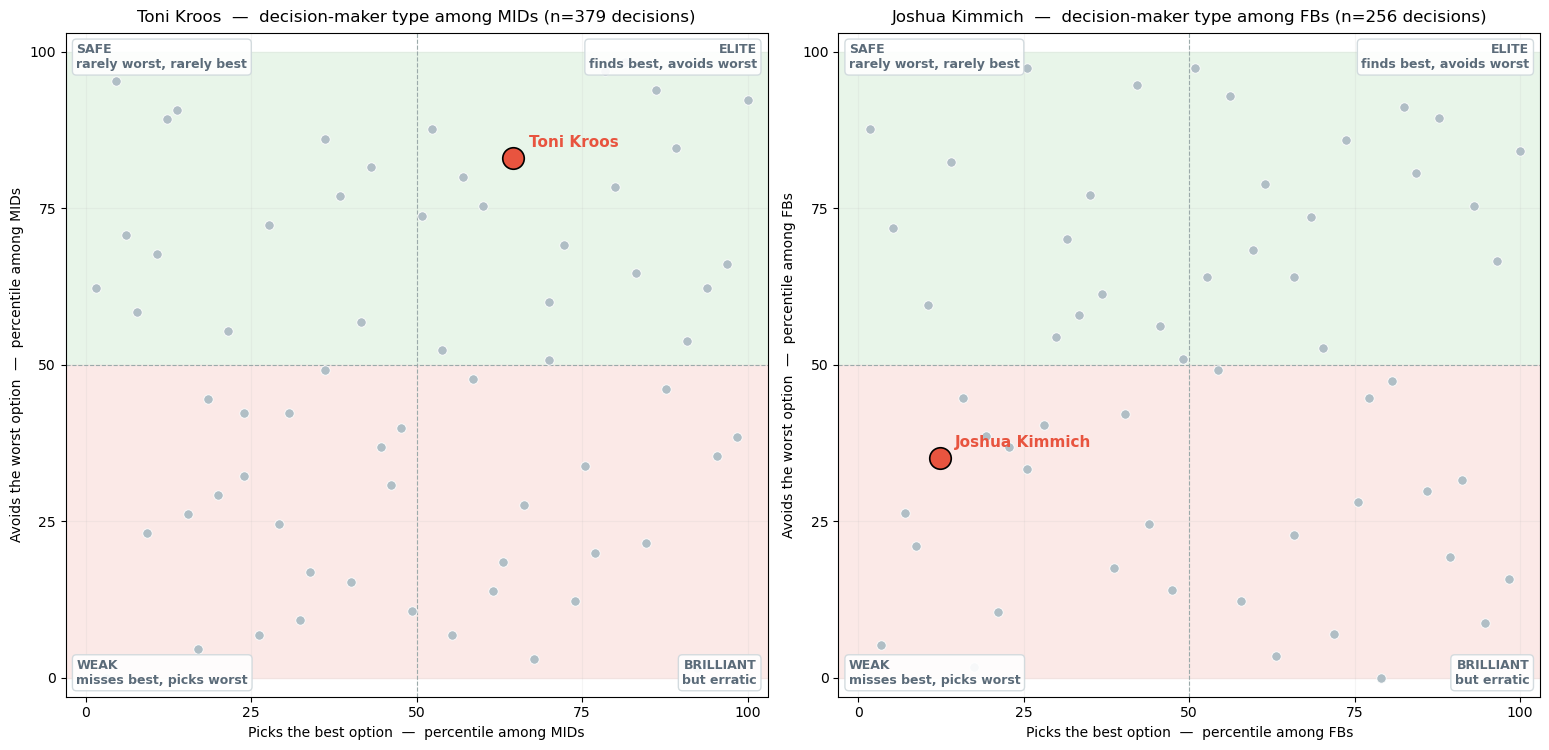

In [18]:
# §6.1 - Decision-maker quadrant (single-player page)
#
# Logic lives in src/viz.plot_dq_quadrant. X = "picks the best option"
# percentile within role, Y = "avoids the worst option" percentile. The
# only page graph whose axes are weakly correlated on this corpus
# (accuracy <-> worst-choice within-role rho ~ 0.12, all four boxes
# populated), so the archetypes are real. DQ_index stays the only
# headline number; raw
# values live in the page table, not on the chart.

dq = pd.read_csv(cfg.PLAYER_DQ_PATH)

fig, axes = plt.subplots(1, 2, figsize=(15.6, 7.6))
viz.plot_dq_quadrant(dq, 'Toni Kroos', ax=axes[0])
viz.plot_dq_quadrant(dq, 'Joshua Kimmich', ax=axes[1])
plt.tight_layout()
plt.show()

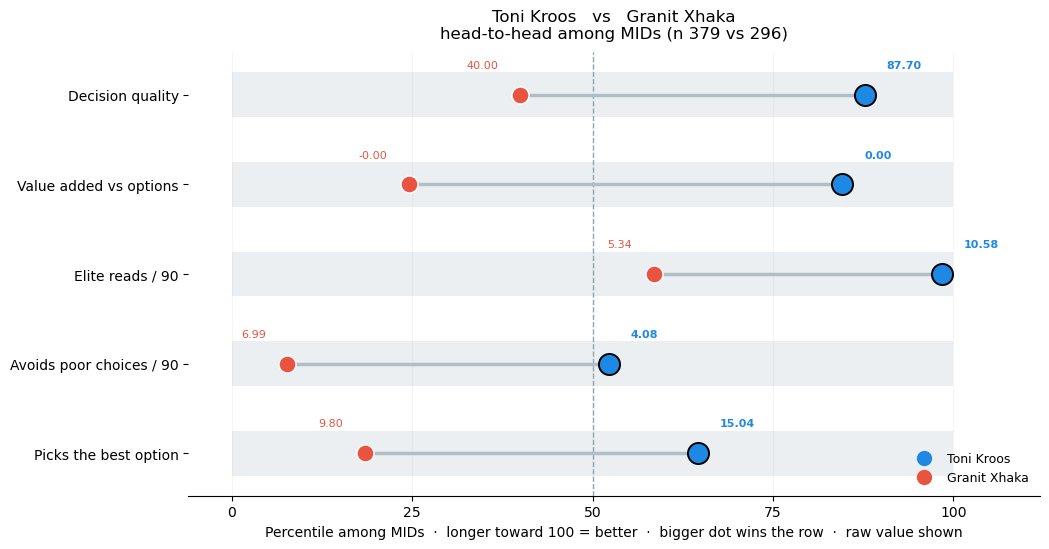

Blocked as designed -> same macro-role only: Kevin De Bruyne is CAM, Toni Kroos is MID. The site restricts the comparison picker to same-role players.


In [19]:
# §6.2 - Head-to-head dumbbell (two-player comparison page)
#
# Logic lives in src/viz.plot_dq_h2h. SAME MACRO-ROLE ONLY: both players
# are percentiled in one identical role pool, so the comparison is direct
# with no "each vs own role" caveat. The site's comparison picker only
# offers same-role players; cross-role is an explicit error here.

# Both MID - a fair, direct head-to-head
fig, ax = plt.subplots(figsize=(10.6, 5.6))
viz.plot_dq_h2h(dq, 'Toni Kroos', 'Granit Xhaka', ax=ax)
plt.tight_layout()
plt.show()

# Cross-role is blocked (the site prevents it upstream)
try:
    viz.plot_dq_h2h(dq, 'Kevin De Bruyne', 'Toni Kroos')
except ValueError as e:
    print('Blocked as designed ->', e)

---

## Output

The website material is written to `data/player_decision_quality.csv`
(272 players, H1's pool): the headline `DQ_index` (within macro-role
percentile of Score), the `value_impact` companion, and the raw / per-90
/ % context block. Chart logic for the two page graphics lives in
`src/viz.py` (`plot_dq_quadrant`, `plot_dq_h2h`); this notebook is only
the orchestrator.

Robustness, construct and face-validity checks are implemented in
`src/validation.py` and were run separately — the index ordering is
stable across the arbitrary knobs, `DQ_index` is not a volume proxy, and
the within-role correlations quoted above (ρ ≈ 0.76 DQ↔Value, ρ ≈ 0.12
picks-best↔picks-worst) are reproducible from that module. The full
design rationale and declared limitations are in
`docs/H2_Decision_Quality_Decisions.docx`.